# Temporal predictors: recording date and construction age

This focused notebook completes the initial **temporal** review of
`date_recorded`, `construction_year`. It describes the supplied training and test predictors,
then uses the labelled training rows to identify relationships worth
carrying into a leakage-safe modelling pipeline.

The two raw columns are audited together because pump age is their meaningful derived relationship.

This is exploratory evidence, not fitted preprocessing. Category pooling,
imputation, encoding and scaling must be learned inside each training fold.


## Consistent audit contract

Every focused predictor audit answers the same questions before adding
type-specific checks:

1. What is explicitly missing, and what looks like a sentinel?
2. What range or category coverage is present in training and test?
3. How much of the test set is exposed to unseen training levels?
4. Does the labelled distribution vary enough to justify retaining the field?
5. What exact baseline treatment follows from the evidence?

Target-rate tables flag support rather than treating tiny groups as reliable.
Train/test comparisons are descriptive and do not use the hidden test labels.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

stage_directory = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "TrainingSetValues.csv").is_file()
)
source_directory = str((stage_directory / "src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from predictor_audit import (
    MISSING_CATEGORY,
    analysis_categories,
    categorical_summary,
    categorical_target_profile,
    category_frequency_table,
    cramer_v,
    hierarchy_conflicts,
    hierarchy_summary,
    numeric_summary,
    numeric_target_summary,
    normalise_categories,
    sentinel_mask,
    source_blank_mask,
    text_normalisation_summary,
)
from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = stage_directory / "data"
training_features = pd.read_csv(
    data_directory / "TrainingSetValues.csv",
    keep_default_na=False,
)
training_labels = pd.read_csv(
    data_directory / "TrainingSetLabels.csv",
    keep_default_na=False,
)
test_features = pd.read_csv(
    data_directory / "TestSetValues.csv",
    keep_default_na=False,
)

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)
audited_features = ['date_recorded', 'construction_year']
assert set(audited_features).issubset(training_features.columns)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
print(
    f"Validated {len(training_features):,} training rows and "
    f"{len(test_features):,} test rows for {len(audited_features)} predictors."
)


Validated 59,400 training rows and 14,850 test rows for 2 predictors.


## 1. Parsing, coverage and unknown years

`date_recorded` is parsed with errors surfaced. A construction year of zero
is handled as unknown, not as a historically meaningful year.


In [2]:
training_dates = pd.to_datetime(training_features["date_recorded"], errors="coerce")
test_dates = pd.to_datetime(test_features["date_recorded"], errors="coerce")

date_summary = pd.DataFrame({
    "rows": [len(training_dates), len(test_dates)],
    "invalid or missing": [training_dates.isna().sum(), test_dates.isna().sum()],
    "minimum": [training_dates.min(), test_dates.min()],
    "maximum": [training_dates.max(), test_dates.max()],
    "unique dates": [training_dates.nunique(), test_dates.nunique()],
    "years": [training_dates.dt.year.nunique(), test_dates.dt.year.nunique()],
    "months represented": [training_dates.dt.month.nunique(), test_dates.dt.month.nunique()],
}, index=["training", "test"])
display(date_summary)
display(
    numeric_summary(
        training_features,
        test_features,
        ["construction_year"],
        sentinel_values_by_column={"construction_year": [0]},
    )
)


,rows,invalid or missing,minimum,maximum,unique dates,years,months represented
training,59400,0,2002-10-14,2013-12-03,356,5,12
test,14850,0,2001-03-26,2013-12-03,331,5,12


rows  missing  sentinel rows  zero rows  \
feature           frame                                                
construction_year training  59400        0          20709      20709   
                  test      14850        0           5260       5260   

                            negative rows  unique  minimum  p01  median  \
feature           frame                                                   
construction_year training              0      55        0  0.0  1986.0   
                  test                  0      55        0  0.0  1986.0   

                                mean     p99  maximum  skewness  
feature           frame                                          
construction_year training  1300.652  2012.0     2013    -0.635  
                  test      1289.708  2012.0     2013    -0.609

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2002,0,0,0,0,0,0,0,0,0,1,0,0
2004,1,0,5,2,2,1,1,2,2,0,0,14
2011,99,2791,11796,3631,30,97,6643,3188,85,93,113,108
2012,2,0,0,0,0,0,0,0,0,5179,1018,225
2013,6252,9611,6135,337,304,248,284,174,241,193,218,274


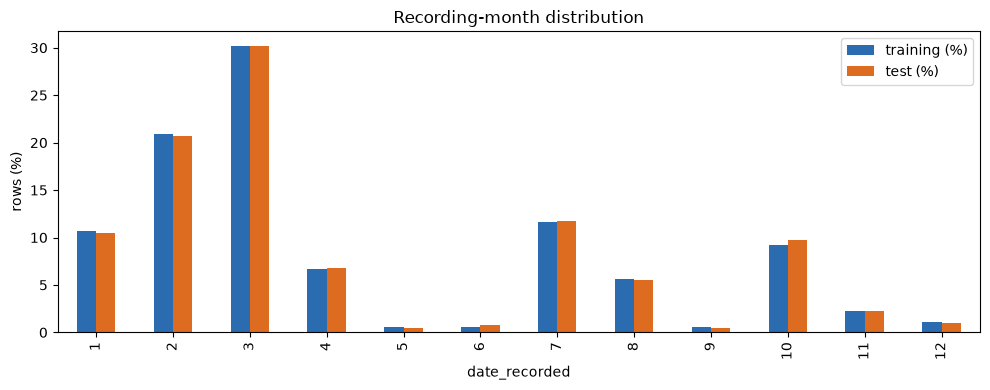

,training (%),test (%)
date_recorded,,
1,10.70,10.43
2,20.88,20.73
3,30.20,30.22
4,6.68,6.77
5,0.57,0.45
6,0.58,0.79
7,11.66,11.69
8,5.66,5.50
9,0.55,0.44


In [3]:
recording_coverage = pd.crosstab(
    training_dates.dt.year.rename("year"),
    training_dates.dt.month.rename("month"),
)
display(recording_coverage)

monthly_share = pd.DataFrame({
    "training (%)": training_dates.dt.month.value_counts(normalize=True).sort_index() * 100,
    "test (%)": test_dates.dt.month.value_counts(normalize=True).sort_index() * 100,
}).fillna(0).round(2)
monthly_share.plot(kind="bar", figsize=(10, 4), color=["#2b6cb0", "#dd6b20"])
plt.title("Recording-month distribution")
plt.ylabel("rows (%)")
plt.tight_layout()
plt.show()
display(monthly_share)


## 2. Derived pump age and validity

Pump age is `recording year - construction year`. It is missing when the
construction year is zero and invalid when negative. Keeping an availability
flag distinguishes unknown age from a genuinely new pump.


In [4]:
def derive_pump_age(features):
    dates = pd.to_datetime(features["date_recorded"], errors="coerce")
    construction_year = pd.to_numeric(features["construction_year"], errors="coerce")
    known_year = construction_year.gt(0)
    age = dates.dt.year.sub(construction_year).where(known_year)
    valid_age = age.where(age.ge(0))
    return pd.DataFrame({
        "recording_year": dates.dt.year,
        "recording_month": dates.dt.month,
        "known_construction_year": known_year,
        "raw_pump_age": age,
        "pump_age": valid_age,
    })

training_temporal = derive_pump_age(training_features)
test_temporal = derive_pump_age(test_features)
age_summary = pd.DataFrame({
    "known construction year (%)": [
        training_temporal["known_construction_year"].mean() * 100,
        test_temporal["known_construction_year"].mean() * 100,
    ],
    "negative ages": [
        training_temporal["raw_pump_age"].lt(0).sum(),
        test_temporal["raw_pump_age"].lt(0).sum(),
    ],
    "median valid age": [
        training_temporal["pump_age"].median(),
        test_temporal["pump_age"].median(),
    ],
    "p90 valid age": [
        training_temporal["pump_age"].quantile(0.90),
        test_temporal["pump_age"].quantile(0.90),
    ],
    "maximum valid age": [
        training_temporal["pump_age"].max(),
        test_temporal["pump_age"].max(),
    ],
}, index=["training", "test"]).round(2)
display(age_summary)


,known construction year (%),negative ages,median valid age,p90 valid age,maximum valid age
training,65.14,9,13.0,35.0,53.0
test,64.58,3,12.0,35.0,53.0


## 3. Relationship with `status_group`

Age bands are descriptive and deliberately broad. The missing band is kept
visible because the absence of a construction year may itself be informative.


In [5]:
labelled_temporal = training_temporal.copy()
labelled_temporal["status_group"] = training_labels["status_group"].to_numpy()
labelled_temporal["age band"] = pd.cut(
    labelled_temporal["pump_age"],
    bins=[-0.001, 0, 5, 10, 20, 30, 40, np.inf],
    labels=["0", "1-5", "6-10", "11-20", "21-30", "31-40", "41+"],
).astype("string").fillna("unknown/invalid")

age_status = pd.crosstab(
    labelled_temporal["age band"],
    labelled_temporal["status_group"],
    normalize="index",
).mul(100).round(2)
age_status.insert(0, "rows", labelled_temporal["age band"].value_counts())
display(age_status)

recording_year_status = pd.crosstab(
    labelled_temporal["recording_year"],
    labelled_temporal["status_group"],
    normalize="index",
).mul(100).round(2)
recording_year_status.insert(
    0, "rows", labelled_temporal["recording_year"].value_counts()
)
display(recording_year_status)


status_group,rows,functional,functional needs repair,non functional
age band,,,,
0,588,70.24,1.87,27.89
1-5,11042,71.60,4.67,23.73
11-20,9456,57.61,6.69,35.69
21-30,5633,44.27,7.39,48.34
31-40,4944,33.23,7.79,58.98
41+,1392,25.00,7.76,67.24
6-10,5627,61.28,8.16,30.57
unknown/invalid,20718,50.97,8.64,40.40


status_group,rows,functional,functional needs repair,non functional
recording_year,,,,
2002,1,100.00,0.00,0.00
2004,30,33.33,3.33,63.33
2011,28674,56.57,6.32,37.11
2012,6424,48.66,5.64,45.70
2013,24271,53.16,8.83,38.02


## 4. Training/test stability

The test set must be representable by transformations defined from training.
Coverage is compared for recording year, month and valid pump age.


In [6]:
temporal_drift = pd.DataFrame({
    "training": [
        training_temporal["recording_year"].min(),
        training_temporal["recording_year"].max(),
        training_temporal["pump_age"].median(),
        training_temporal["known_construction_year"].mean() * 100,
    ],
    "test": [
        test_temporal["recording_year"].min(),
        test_temporal["recording_year"].max(),
        test_temporal["pump_age"].median(),
        test_temporal["known_construction_year"].mean() * 100,
    ],
}, index=[
    "minimum recording year",
    "maximum recording year",
    "median valid pump age",
    "known construction year (%)",
]).round(2)
display(temporal_drift)


,training,test
minimum recording year,2002.00,2001.00
maximum recording year,2013.00,2013.00
median valid pump age,13.00,12.00
known construction year (%),65.14,64.58


## Decision register

The register separates observed evidence from the proposed baseline action.
A retained field is still a candidate: later validation must show whether it
improves generalisation and whether a coarser related representation is safer.


In [7]:
decision_register = pd.DataFrame([{'feature': 'date_recorded', 'quality finding': 'All dates parse; training spans 2002-10-14 to 2013-12-03 with strong survey-month differences.', 'baseline treatment': 'Derive recording year/month and elapsed days; do not one-hot the raw date string.', 'risk to verify': 'Collection timing can proxy geography or survey operations.'}, {'feature': 'construction_year', 'quality finding': 'Year zero affects 34.86%; valid pump age has median 13 and nine negative training cases.', 'baseline treatment': 'Keep unknown/inconsistent flags and valid pump age; compare construction cohort.', 'risk to verify': 'Imputation and age construction must be fitted or applied without validation leakage.'}])
display(decision_register.set_index("feature"))


,quality finding,baseline treatment,risk to verify
feature,,,
date_recorded,All dates parse; training spans 2002-10-14 to 2013-12-03 with strong survey-...,Derive recording year/month and elapsed days; do not one-hot the raw date st...,Collection timing can proxy geography or survey operations.
construction_year,Year zero affects 34.86%; valid pump age has median 13 and nine negative tra...,Keep unknown/inconsistent flags and valid pump age; compare construction coh...,Imputation and age construction must be fitted or applied without validation...


### Handoff to modelling

Compute age row by row, then fit any age imputation only on the training fold.

- Preserve raw source frames and implement the stated sentinel rules on copies.
- Fit imputers, rare-level grouping and encoders on each training fold only.
- Map unseen validation or test categories to an explicit fallback.
- Compare the stated baseline treatment with a simple omission ablation.
- Revisit target-rate observations after the reproducible stratified split exists.
